# Proteome Composition Confounds Species-Specific Bias in ESM-2 Log-Likelihoods

## Abstract

This notebook aims to quantify the difference in log-likelihoods under ESM-2 between model and non-model organisms.  When comparing the full proteomes, there is a significant difference in log-likelihoods between the model organism, *E. coli*, and the non-model organism, *A. baylyi*. However, the difference vanishes when controlling for protein family composition using paired homologs suggesting proteome composition is driving the difference, not species-specific bias. To account for non-normal and asymmetric log-likelihood differences between the *A. baylyi* and *E. coli* proteomes, we used the Sign test and Bootstrapped Median.


## Introduction


Protein language models are trained on large sequence databases such as UniRef and reflect the biases within these databases. Scientists have sequenced a handful of species more in-depth than others, leading to databases with incomplete genes and limited sequence variation for underrepresented species. This species bias can manifest in PLMs when proteins of overrepresented organisms are assigned higher likelihoods, as they were more represented during model training. **This notebook examines differences in protein sequence log-likelihood under the ESM-2 model for a model and a non-model organism.**


## Motivating work


[Ding and Steinhart 2024](https://www.biorxiv.org/content/10.1101/2024.03.07.584001v1.full) introduce an Elo-based ranking metric quantifying the bias overrepresented species have on likelihoods assigned under PLMs.

**Project Question**: Does the distribution of protein sequence likelihoods differ across organisms under the ESM-2 protein language model?


## Hypothesis


ESM-2 assigns higher likelihoods to proteins from model organisms than proteins from non-model organisms, reflective of their representation in the training data.


## Project Goals


1. Compare ESM-2 negative log-likelihoods and perplexity scores across the proteomes of model and non-model organisms.
2. Define a set of putative homologs using sequence similarity.
3. Compare ESM-2 negative log-likelihoods using putative homologs to control for protein family composition.

## Organisms


- Model organism: *Escherichia coli (strain K12)* (taxid: 83333)
- Non-model organism: *Acinetobacter baylyi (strain ATCC 33305 / BD413 / ADP1)* (taxid: 62977)

These organisms were chosen as examples in [Ding and Steinhart 2024](https://www.biorxiv.org/content/10.1101/2024.03.07.584001v1.full).


<img src="https://lucid.app/publicSegments/view/0899b865-7414-4430-8f96-1aee813596e3/image.png" width="500">

# 00: Install and import relevant packages.

- tqdm, pandas, numpy, scipy, seaborn, matplotlib, and torch are standard dependencies.
- fair-esm: python module to load ESM model parameters and compute likelihoods.
- ncbi-blast+: command-line program to compute sequence-to-sequence alignment.
- [homolog-search-tools](https://github.com/chrisnguyen11/homolog-search-tools): python package with functions to interact with ncbi-blast via python and process sequence data.

In [ ]:
!pip install fair-esm --quiet
!apt-get -qq install ncbi-blast+
!pip install git+https://github.com/chrisnguyen11/homolog-search-tools.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.6 MB/s eta 0:00:00
Selecting previously unselected package ncbi-data.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb ...
Unpacking ncbi-blast+ (2.12.0+ds-3build1) ...
Setting up ncbi-data (6.1.20170106+dfsg1-9) ...
Setting up ncbi-blast+ (2.12.0+ds-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for hicolor-icon-theme (0.17-2) ...
  Preparing metadata (setup.py) ... done


In [ ]:
# utility
from tqdm.notebook import tqdm

# data science and visualization
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# deep-learning
import torch

# protein sequence modeling
import esm
from homolog_search_tools.utils import read_fasta, write_fasta
from homolog_search_tools.similarity import BlastP


# 01: Prepare sequences.

Filter sequences to ensure reliable ESM-2 computations and BLASTP sequence alignments.

In [ ]:
def fasta_to_dataframe(fasta_path, skip_seq_char="*"):
  """
  Convert fasta files into pandas dataframe
  while removing records containing skip_seq_char.

  Parameters
  ----------
  fasta_path: str
    Path to fasta file.
  skip_seq_char: str
  """
  headers, seqs = read_fasta(fasta_path)
  df = pd.DataFrame({"Header": headers, "Sequence": seqs})
  skip_df = df[df["Sequence"].str.contains(skip_seq_char, regex=False)]

  print(f"Read {len(headers)} and removed {len(skip_df)} sequences")
  return df.drop(skip_df.index)

In [ ]:
seqs_83333_df = fasta_to_dataframe("proteome-taxid_83333.fasta")
seqs_62977_df = fasta_to_dataframe("proteome-taxid_62977.fasta")

Read 4318 and removed 2 sequences
Read 3310 and removed 0 sequences


In [ ]:
write_fasta(seqs_83333_df, "pruned-proteome-taxid_83333.fasta")

# 02: Compute negative log-likelihood under ESM-2.

ESM-2 is a masked language model using context before and after a masked position to predict the identity of the masked token. In this project, each sequence is evaluated in a single pass by summing the negative log conditional probability of every amino acid.

See [Lin et al. 2023](https://www.science.org/doi/10.1126/science.ade2574) for more details on ESM-2 and the corresponding [GitHub repo](https://github.com/facebookresearch/esm) for the function to extract log-likelihoods under the ESM model.


Note: As opposed to performing L passes per sequence, where each residue is masked and scored independently:

> $\log{P(x)} = \frac{1}{L} \sum_{i=0}^{L} - \log{P(x_i|x_{\backslash i})}$

where $x_{\backslash i}$ is the sequence without the $i^{th}$ amino acid.

In [ ]:
# load ESM model parameters and encoder
model, alphabet =  esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


In [ ]:
def extract(
    model, alphabet, sequences, repr_layers=[], agg="mean",
    truncation_seq_length=1022,
    toks_per_batch=4096, ALPHABET = "LAGVSERTIDPKQNFWYMHC",
    device="cuda"
    ):
  """
  Extracts and processes sequence representations using ESM-2. Code modified
  from the [extract.py](https://github.com/facebookresearch/esm/blob/main/scripts/extract.py)
  in the ESM repo.

  Parameters
  ----------
  model: str
    ESM model object.
  alphabet: str
    ESM alphabet object.
  sequences: str
    Path to fasta file.
  repr_layers: list[int]
    List of layers to extract representations from.
  """
  # Load model parameters and sequence data
  model.to(device)
  model.eval()
  dataset = esm.FastaBatchedDataset.from_file(sequences)
  batches = dataset.get_batch_indices(toks_per_batch, extra_toks_per_seq=1)
  data_loader = torch.utils.data.DataLoader(
    dataset, collate_fn=alphabet.get_batch_converter(truncation_seq_length),
    batch_sampler=batches
  )
  tok_to_idx = alphabet.tok_to_idx

  # Inference
  with torch.no_grad():
    output = []
    for batch_idx, (labels, strs, toks) in tqdm(enumerate(data_loader)):
      toks = toks.to(device=device) # Move toks to the specified device
      batch_output = model(toks, repr_layers=repr_layers)
      batch_logits = batch_output["logits"].to(device=device)

      for i, label in enumerate(labels):
        # Compute LL
        seq_length = truncation_seq_length if len(strs[i]) > truncation_seq_length else len(strs[i])
        batch_probs = torch.nn.functional.softmax(batch_logits[i, 1:seq_length+1], dim=1)
        batch_log_probs = torch.log(batch_probs)
        residue_log_probs = [batch_log_probs[j, tok_to_idx[aa]].item() for j, aa in enumerate(strs[i]) if j < seq_length]

        log_prob = (1/seq_length) * np.sum(residue_log_probs)

        perplexity = np.exp(-log_prob)

        # Save sequence data
        _output = {
            "Sequence":strs[i], "perplexity":perplexity, "log_likelihood":log_prob,
            "batch_probs": batch_probs
            }
        if len(repr_layers) > 0:
          batch_representations = {
            layer: rep.to(device="cpu") for layer, rep in batch_output["representations"].items()
          }
          _output["embedding"] = batch_representations[repr_layers[0]][i, 1:seq_length+1].numpy()
          _output["mean_embedding"] = batch_representations[repr_layers[0]][i, 1:seq_length+1].mean(0).numpy()
        output.append(_output)
  return output

In [ ]:
esm_83333 = extract(model, alphabet, "pruned-proteome-taxid_83333.fasta", repr_layers=[])

0it [00:00, ?it/s]

In [ ]:
esm_62977 = extract(model, alphabet, "proteome-taxid_62977.fasta", repr_layers=[])

0it [00:00, ?it/s]

In [ ]:
esm_83333_df = seqs_83333_df.merge(
    pd.DataFrame(esm_83333), on="Sequence", how="left").drop(columns=["Sequence"])
esm_83333_df["Shorten-Header"] = esm_83333_df["Header"].apply(lambda x: x.split(" ")[0])

esm_62977_df = seqs_62977_df.merge(
    pd.DataFrame(esm_62977), on="Sequence", how="left"
).drop(columns=["Sequence"])
esm_62977_df["Shorten-Header"] = esm_62977_df["Header"].apply(lambda x: x.split(" ")[0])

In [ ]:
stats.kstest(esm_83333_df["log_likelihood"], esm_62977_df["log_likelihood"])

KstestResult(statistic=np.float64(0.03205307850044692), pvalue=np.float64(0.03706042946726736), statistic_location=np.float64(-0.366042103068859), statistic_sign=np.int8(-1))

Across the full proteomes, there is a significant difference in the negative log-likelihood distributions between *E. coli* and *A. baylyi*, based on the Kolmogorov–Smirnov test.

**However, this significant difference may reflect the proteomes' protein family compositions rather than just the species-specific effect.** Protein family composition is a function of evolutionary history and environment, so the difference we are detecting may reflect protein family compositions rather than a species-specific PLM bias.

**To control for protein family composition, we can pair sequences between the proteomes from the same or similar protein families, then test if there is a difference in negative log-likelihoods between *E. coli* and *A. baylyi*.**

# 03: Assigning putative homologs between organisms.


Use sequence similarity to quantify relatedness between protein sequences and define putative homology. BLAST is the primary tool to estimate sequence similarity by computing E-values, the expected value of alignments with scores greater than or equal to the observed score.
*  E-values incorporate the number of sequences being aligned to.
*  E-values closer to 0 indicate a biologically meaningful alignment.
*  Log transform E-values to spread small E-values.


Refer to the [BLAST manual](https://www.ncbi.nlm.nih.gov/books/NBK279690/) for details on command parameters and [Metagenomics wiki](https://www.metagenomics.wiki/tools/blast/evalue) for a high level summary of E-values.

In [ ]:
# run blastp twice so each organism is both the subject and query
blastp = BlastP()
_similarity_1 = blastp.run(seqs_83333_df, seqs_62977_df)
_similarity_2 = blastp.run(seqs_62977_df, seqs_83333_df)

In [ ]:
similarity_df = pd.concat([_similarity_1, _similarity_2]
    ).sort_values("Log_E_Value", ascending=False
    ).drop_duplicates(subset=["Accession_1","Accession_2"], keep="first"
    )

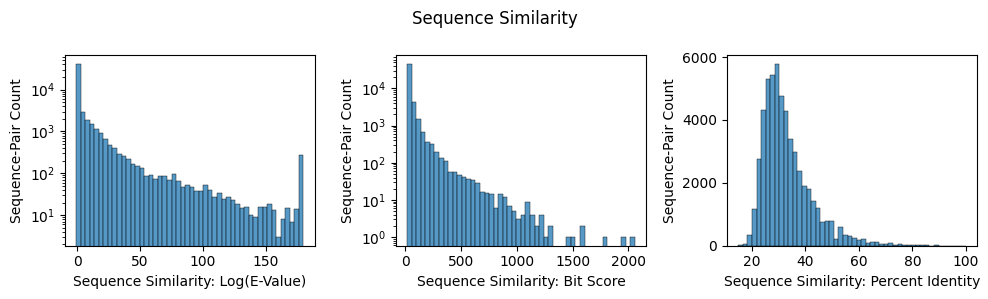

In [ ]:
# Plot distribution of sequence similarity scores between organisms.

fig, ax = plt.subplots(1, 3, figsize=(10, 3))

plt.suptitle("Sequence Similarity")
sns.histplot(data=similarity_df, x="Log_E_Value", bins=50, ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_xlabel("Sequence Similarity: Log(E-Value)")
ax[0].set_ylabel("Sequence-Pair Count")

sns.histplot(data=similarity_df, x="Bit_Score", bins=50, ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_xlabel("Sequence Similarity: Bit Score")
ax[1].set_ylabel("Sequence-Pair Count")

sns.histplot(data=similarity_df, x="Percent_Identity", bins=50, ax=ax[2])
ax[2].set_xlabel("Sequence Similarity: Percent Identity")
ax[2].set_ylabel("Sequence-Pair Count")

plt.tight_layout()

The majority of the sequences show weak similarity between the E. coli and A. baylyi proteomes. In the *Sequence Similarity: Percent Identity plot*, the density lies between 20% and 35%, known as the twilight zone, a range commonly thought to be difficult to distinguish homology.

On the right side of the plots, there are pairs of sequences showing high sequence similarity with potential candidates for homologs.


### Define putative homologs between organisms.

BLAST can report multiple local alignments for a pair of sequences, therefore each protein will contribute once towards its most evolutionarily meaningful homolog.

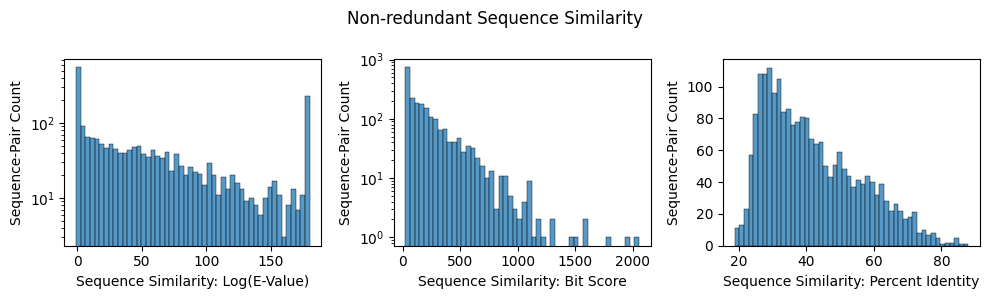

In [ ]:
similarity_nonredundant_df = similarity_df.drop_duplicates(
    subset=["Accession_1"], keep="first"
    ).drop_duplicates(subset=["Accession_2"], keep="first")

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
plt.suptitle("Non-redundant Sequence Similarity")

sns.histplot(data=similarity_nonredundant_df, x="Log_E_Value", bins=50, ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_xlabel("Sequence Similarity: Log(E-Value)")
ax[0].set_ylabel("Sequence-Pair Count")

sns.histplot(data=similarity_nonredundant_df, x="Bit_Score", bins=50, ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_xlabel("Sequence Similarity: Bit Score")
ax[1].set_ylabel("Sequence-Pair Count")

sns.histplot(data=similarity_nonredundant_df, x="Percent_Identity", bins=50, ax=ax[2])
ax[2].set_xlabel("Sequence Similarity: Percent Identity")
ax[2].set_ylabel("Sequence-Pair Count")
plt.tight_layout()

When removing the redundant alignments, the density of the Percent Identity plot shifts away from the 20% range towards higher similarity values. The shift to more similarity alignments is less pronounced in the Log(E-value) and Bit Score plots.

### Compare Log(E-value) to Percent Identity.

Although not biologically meaningful, this plot gives an intuition of the relationship between the Log(E-value) and a more familiar metric, Percent Identity, for this particular dataset.


Text(0.5, 0.98, 'Local Percent Identity vs. Log(E-Value)')

<Figure size 640x480 with 0 Axes>

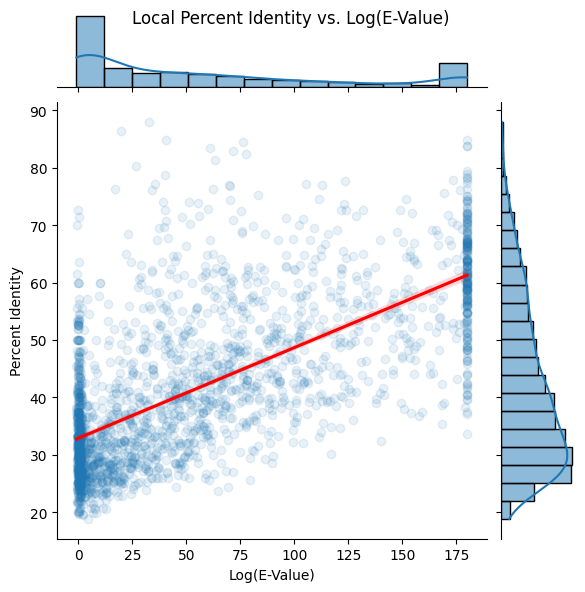

In [ ]:
fig = plt.figure()
sns.jointplot(data=similarity_nonredundant_df, x="Log_E_Value", y="Percent_Identity",
              kind="reg", scatter_kws={"alpha": 0.1}, line_kws={"color": "red"}
            )
plt.xlabel("Log(E-Value)")
plt.ylabel("Percent Identity")
plt.suptitle("Local Percent Identity vs. Log(E-Value)")

There is no one-to-one relationship between Log(E-Value) and Percent Identity; the Percent Identity reported was computed on the locally aligned fragment between the two sequences and does not account for the full length of either sequence.


On average, for this dataset,
- Log(E-Values) near 0 corresponds to about a 35 Percent Identity between the two sequences, and
- Log(E-Value) of 180 corresponds to about 60 Percent Identity.

# 04: Analysis of log-likelihoods of proteomes and homologs.

Compare the difference in negative log-likelihood for the putative homologs.

In [ ]:
esm_83333_df["Organism"] = "E. coli"
esm_62977_df["Organism"] = "A. baylyi"

esm_long_df = pd.concat([esm_62977_df, esm_83333_df])

In [ ]:
# merge sequence similarity data with esm scores
similarity_esm_df = similarity_nonredundant_df[["Accession_1","Accession_2","E_Value","Bit_Score","Log_E_Value"]].merge(
    esm_83333_df, left_on="Accession_2", right_on="Shorten-Header",
    how="left"
).merge(
    esm_62977_df, left_on="Accession_1", right_on="Shorten-Header",
    how="left", suffixes=("_83333", "_62977")
).drop(columns=[
    "Accession_1","Shorten-Header_83333", "Accession_2","Shorten-Header_62977"
    ])
similarity_esm_df["Perplexity_Difference"] = similarity_esm_df["perplexity_62977"] - similarity_esm_df["perplexity_83333"]
similarity_esm_df["Log_Likelihood_Difference"] = similarity_esm_df["log_likelihood_62977"] - similarity_esm_df["log_likelihood_83333"]

## Do the putative homologs represent the full proteome?

Before comparing the difference between the species, we must ensure that the putative homologs represent each proteome's negative log-likelihood distributions.

We refine a subset such that only the pairs of sequences for which the Kolmogorov-Smirnov test shows no significant difference between the subset and full proteome for both organisms.

kstest A. baylyi: test-statistic:0.02, p-value:0.86061
kstest E. coli: test-statistic:0.08, p-value:0.00000


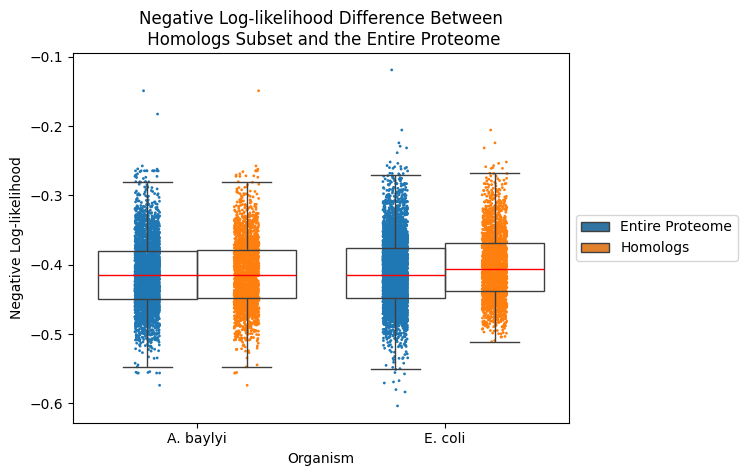

In [ ]:
similarity_subset = similarity_nonredundant_df
similarity_accessions = pd.concat([similarity_subset["Accession_1"], similarity_subset["Accession_2"]])
esm_long_similarity_df = esm_long_df[esm_long_df["Shorten-Header"].isin(similarity_accessions)]
esm_long_similarity_df = esm_long_similarity_df.assign(Subset="Homologs")

data = pd.concat([esm_long_df, esm_long_similarity_df])
data["Subset"] = np.where(data["Subset"].isna(), "Entire Proteome", data["Subset"])

ks_statistic_62977, ks_p_62977 = stats.kstest(
    data[(data["Organism"] == "A. baylyi") & (data["Subset"] == "Homologs")]["log_likelihood"],
    data[(data["Organism"] == "A. baylyi") & (data["Subset"] == "Entire Proteome")]["log_likelihood"]
)
ks_statistic_83333, ks_p_83333 = stats.kstest(
    data[(data["Organism"] == "E. coli") & (data["Subset"] == "Homologs")]["log_likelihood"],
    data[(data["Organism"] == "E. coli") & (data["Subset"] == "Entire Proteome")]["log_likelihood"]
)

sns.stripplot(data=data, x="Organism", y="log_likelihood", hue="Subset",
              dodge=True, s=2, legend=False, zorder=0)
sns.boxplot(data=data, x="Organism", y="log_likelihood", hue="Subset",
            dodge=True, showfliers=False, boxprops={'facecolor':'None'},
            medianprops={"color": "r"})
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Negative Log-likelihood Difference Between\n Homologs Subset and the Entire Proteome")
plt.ylabel("Negative Log-likelihood")

print(f"kstest A. baylyi: test-statistic:{ks_statistic_62977:.2f}, p-value:{ks_p_62977:.5f}")
print(f"kstest E. coli: test-statistic:{ks_statistic_83333:.2f}, p-value:{ks_p_83333:.5f}")

The *E. coli* subset does not adequately represent the proteome well, so we prune our list of homologs accordingly.


We can repeat this analysis on a range of potential subsets, progressively removing less significant homologs, using Log(E-value) as the metric of homolog significance.

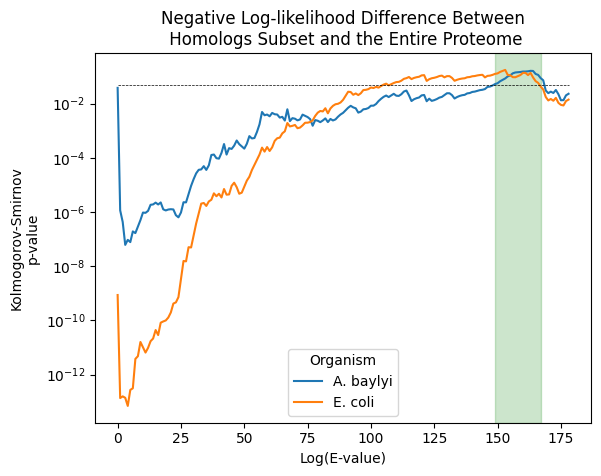

In [ ]:
evalue_min = int(similarity_nonredundant_df["Log_E_Value"].min())
evalue_max = int(similarity_nonredundant_df["Log_E_Value"].max())

sweep = {}
for threshold in range(evalue_min, evalue_max, 1):
  similarity_subset = similarity_nonredundant_df[similarity_nonredundant_df["Log_E_Value"] > threshold]
  similarity_accessions = pd.concat([similarity_subset["Accession_1"], similarity_subset["Accession_2"]])
  esm_long_similarity_df = esm_long_df[esm_long_df["Shorten-Header"].isin(similarity_accessions)]
  esm_long_similarity_df = esm_long_similarity_df.assign(Subset="Homologs")

  data = pd.concat([esm_long_df, esm_long_similarity_df])
  data["Subset"] = np.where(data["Subset"].isna(), "Entire Proteome", data["Subset"])

  ks_statistic_62977, ks_p_62977 = stats.kstest(
      data[(data["Organism"] == "A. baylyi") & (data["Subset"] == "Homologs")]["log_likelihood"],
      data[(data["Organism"] == "A. baylyi") & (data["Subset"] == "Entire Proteome")]["log_likelihood"]
  )
  ks_statistic_83333, ks_p_83333 = stats.kstest(
      data[(data["Organism"] == "E. coli") & (data["Subset"] == "Homologs")]["log_likelihood"],
      data[(data["Organism"] == "E. coli") & (data["Subset"] == "Entire Proteome")]["log_likelihood"]
  )
  ks_statistic, ks_p = stats.kstest(
      data[(data["Organism"] == "A. baylyi") & (data["Subset"] == "Homologs")]["log_likelihood"],
      data[(data["Organism"] == "E. coli") & (data["Subset"] == "Homologs")]["log_likelihood"],
  )

  sweep[threshold] = {
      "ks_statistic_A. baylyi": ks_statistic_62977,
      "ks_p_A. baylyi": ks_p_62977,
      "ks_statistic_E. coli": ks_statistic_83333,
      "ks_p_E. coli": ks_p_83333,
      "subset_size": len(data[(data["Organism"] == "E. coli") & (data["Subset"] == "Homologs")]),

  }

sweep_df = pd.DataFrame(sweep).T
sweep_df = sweep_df.reset_index().rename(columns={"index": "Log_E_Value"})
sweep_long_df = sweep_df.melt(id_vars=["Log_E_Value"], value_vars=["ks_p_A. baylyi", "ks_p_E. coli"], var_name="Organism",value_name="p-value")

sweep_long_df["Organism"] = sweep_long_df["Organism"].str.replace("ks_p_", "")

sns.lineplot(sweep_long_df, x="Log_E_Value", y="p-value", hue="Organism")
plt.hlines(0.05, sweep_df["Log_E_Value"].min(), sweep_df["Log_E_Value"].max(),
           linestyles="--", color="black", linewidth=0.5)
plt.yscale('log')
plt.ylabel("Kolmogorov-Smirnov\np-value")
plt.xlabel("Log(E-value)")
plt.title("Negative Log-likelihood Difference Between\n Homologs Subset and the Entire Proteome")

plt.axvspan(149, 167, color="green", alpha=0.2)

A good subset of homologs is one where there is **no significant difference** in negative log-likelihoods between the subset of homologs and the entire proteome. In other words, the subset of homologs represents the distribution of the entire proteome.


A lower bound on the Log(E-value) between 149 and 167 defines homologous subsets that well represent the negative log-likelihood distributions for both the A. baylyi and E. coli proteomes.


Let's examine the subset where Log(E-value) > 160.

NormaltestResult(statistic=np.float64(13.27147561011035), pvalue=np.float64(0.001312609937560893))

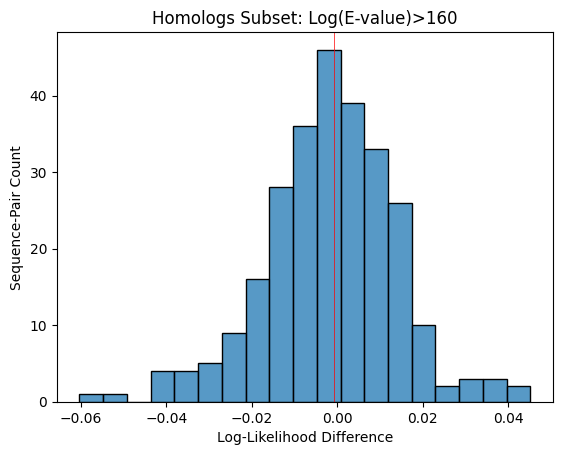

In [ ]:
threshold = 160

data = similarity_esm_df[similarity_esm_df["Log_E_Value"]> threshold]
sns.histplot(data=data, x="Log_Likelihood_Difference")
plt.axvline(data["Log_Likelihood_Difference"].median(),
            color="red", linestyle="-", linewidth=0.5)
plt.xlabel("Log-Likelihood Difference")
plt.ylabel("Sequence-Pair Count")
plt.title("Homologs Subset: Log(E-value)>160")
stats.normaltest(data["Log_Likelihood_Difference"])

For the subset defined by Log(E-value)>160, the difference in log-likelihood between *A. baylyi* and *E. coli* is non-normal normality test $p_{value} < 0.005$ therefore we cannot use the paired t-test. Looking at the distribution of differences, the log-likelihood differences are not symmetric about the median, the negative tail is long and there is a mass imbalance near the median. Therefore we cannot use the Wilcoxon Signed-Rank test. The Sign test is appropriate for identifying the direction and bootstrapped median will identify the magnitude of the log-likelihood difference.

In [ ]:
def difference_summary_statistics(difference):
  sign_test_result = stats.binomtest(
      np.sum(difference > 0), len(difference), p=0.5, alternative="two-sided"
  )

  bootstrap_result = stats.bootstrap(
      (difference,), np.median, confidence_level=0.95,
      method="BCa", n_resamples=10000,
  )
  return {
      "Sign Test": {
          "Test Statistic": sign_test_result.statistic,
          "p-value": sign_test_result.pvalue
      },
      "Bootstrapped Median": {
        "Median": np.median(difference), "CI low": bootstrap_result.confidence_interval.low,
        "CI high": bootstrap_result.confidence_interval.high, "SE": bootstrap_result.standard_error
      }
  }

In [ ]:
difference_summary_statistics(data["Log_Likelihood_Difference"])

{'Sign Test': {'Test Statistic': 0.4626865671641791,
  'p-value': np.float64(0.24575030146283117)},
 'Bootstrapped Median': {'Median': np.float64(-0.0007526721885353915),
  'CI low': np.float64(-0.002607000338037957),
  'CI high': np.float64(0.000871578873427814),
  'SE': np.float64(0.0008354385401975002)}}

For the subset defined by Log(E-value)>160, Sign test of 0.46 indicates that the log-likelihood difference is faily balanced between positive and negative values, the $p_value = 0.25$ suggest that the median log-likelihood difference is 0 for our paired test.

The Bootstrapped Median confidence interval (95% [-0.00260, 0.00087]) includes 0, therefore we are not 95% certain that the true median is positive or negative.

There is no significant difference between the paired homologs from *E. coli* and *A. baylyi* using the Sign test and Bootstrapped median. This suggests that a species-specific effect is not a driving the difference between these two full proteomes.

## Difference in negative log-likelihood for the putative homologs

For the defined subsets, test if there is a significant difference in negative log-likelihood between the paired E. coli and A. baylyi sequences.

In [ ]:
evalue_sweep = []
for threshold in tqdm(range(evalue_min, evalue_max, 1)):
  data = similarity_esm_df[similarity_esm_df["Log_E_Value"]> threshold]
  evalue_sweep.append(
      difference_summary_statistics(data["Log_Likelihood_Difference"]) | {
      "threshold": threshold,
      "subset_size": len(data),

  })
evalue_sweep_df = pd.DataFrame(evalue_sweep)

  0%|          | 0/179 [00:00<?, ?it/s]

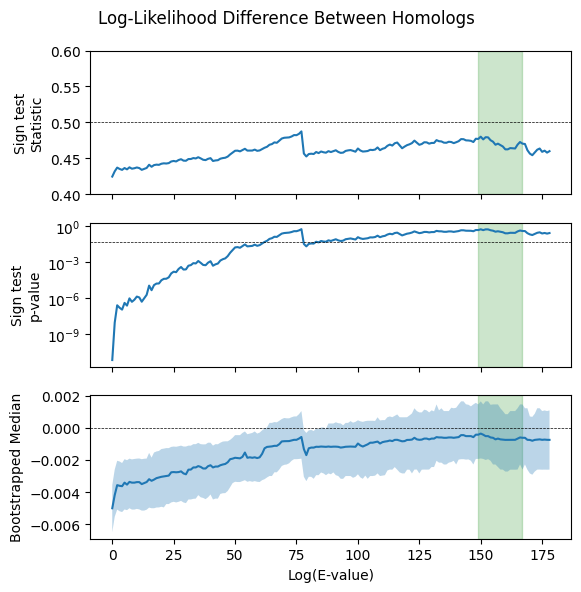

In [ ]:
evalue_sweep_df["Sign Test Statistic"] = evalue_sweep_df["Sign Test"].apply(lambda x: x["Test Statistic"])
evalue_sweep_df["Sign Test p-value"] = evalue_sweep_df["Sign Test"].apply(lambda x: x["p-value"])
evalue_sweep_df["Bootstrapped Median Statistic"] = evalue_sweep_df["Bootstrapped Median"].apply(lambda x: x["Median"])
evalue_sweep_df["Bootstrapped CI low"] = evalue_sweep_df["Bootstrapped Median"].apply(lambda x: x["CI low"])
evalue_sweep_df["Bootstrapped CI high"] = evalue_sweep_df["Bootstrapped Median"].apply(lambda x: x["CI high"])


fig, ax = plt.subplots(3,1, sharex=True, figsize=(6, 6))
plt.suptitle("Log-Likelihood Difference Between Homologs")

sns.lineplot(evalue_sweep_df, x="threshold", y="Sign Test Statistic", ax=ax[0])
ax[0].set_ylabel("Sign test\nStatistic")
ax[0].set_xlabel("Log(E-value)")
ax[0].axhline(0.5, color="black", linestyle="--", linewidth=0.5)
ax[0].axvspan(149, 167, color="green", alpha=0.2)
ax[0].set_ylim(0.4, 0.6)

sns.lineplot(evalue_sweep_df, x="threshold", y="Sign Test p-value", ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_ylabel("Sign test\np-value")
ax[1].set_xlabel("Log(E-value)")
ax[1].axhline(0.05, color="black", linestyle="--", linewidth=0.5)
ax[1].axvspan(149, 167, color="green", alpha=0.2)

sns.lineplot(evalue_sweep_df, x='threshold', y="Bootstrapped Median Statistic", ax=ax[2])
ax[2].axhline(0, color="black", linestyle="--", linewidth=0.5)
ax[2].axvspan(149, 167, color="green", alpha=0.2)
ax[2].fill_between(evalue_sweep_df['threshold'], evalue_sweep_df['Bootstrapped CI low'], evalue_sweep_df['Bootstrapped CI high'], alpha=0.3)
ax[2].set_ylabel("Bootstrapped Median")
ax[2].set_xlabel("Log(E-value)")
plt.tight_layout()

The Sign test statistic is near 0.5 in this region indicating that the difference between the log-likelihoods of *A. baylyi* and *E. coli* is balance between positive and negative values. The Sign test p-value in the region is $p_{value} \in [0.245, 0.528]$ indicating that the median for the paired test is 0. The bootstrapped median for the region includes 0 therefore we are unable to determine with 95% certainity that the median is positve or negative.

Therefore the regions where the homologous subsets represent the proteomes well (in green), there is no statistically significant difference between *A. baylyi* and *E. coli*.

In [ ]:
evalue_sweep_df.iloc[149:167].describe()

,threshold,subset_size,Sign Test Statistic,Sign Test p-value,Bootstrapped Median Statistic,Bootstrapped CI low,Bootstrapped CI high
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,157.500000,277.444444,0.470909,0.373285,-0.000631,-0.002342,0.001297
std,5.338539,15.139439,0.006110,0.097607,0.000129,0.000305,0.000267
min,149.000000,258.000000,0.462687,0.245750,-0.000753,-0.002723,0.000845
25%,153.250000,267.250000,0.464981,0.278172,-0.000746,-0.002606,0.001038
50%,157.500000,271.500000,0.469910,0.357683,-0.000672,-0.002362,0.001440
75%,161.750000,288.500000,0.476221,0.448728,-0.000540,-0.002016,0.001452
max,166.000000,306.000000,0.480263,0.528179,-0.000361,-0.001910,0.001646


# Takeaways


This project examines two bacterial species: one model organism, *E. coli*, and one non-model organism, *A. baylyi*.


Under ESM-2, there is a statistically significant difference in the negative log-likelihoods between the full proteomes of *E. coli* and *A. baylyi*, but it is confounded by the proteome protein composition. In other words, it is unclear if the statistically significant difference reflects a difference in proteome protein family composition or a species-specific training bias.


To control for the protein family composition in the proteomes, we define a set of putative homologs to capture proteins of similar or the same protein family from both organisms. BLASTP was used to identify similar sequences between *E. coli* and *A. baylyi*, with the metric Log(E-value) quantifying the pairwise sequence similarity. Putative homologs were defined by iteratively sweeping Log(E-value) thresholds such that a set represented each full proteome's negative log-likelihood distribution using the Kolmogorov-Smirnov test.

For the representative putative homologous sets, the distribution of log-likelihood differences is non-normal and asymmetric therefore we cannot use the paired t-test or Wilcoxon Signed-Rank test. To be robust to the negative tails we used the Sign test and Bootstrapped Median. The Sign test statistic is near 0.5 with p-values between [0.245, 0.528] and the confidence interval for the Bootstrapped Median includes 0 therefore there is no significant difference between *E. coli* and *A. baylyi*, suggesting the protein family composition is driving the difference rather than a species-specific effect. However, this analysis does not rule out a species-specific effect, but the method of comparing the *E. coli* and *A. baylyi* proteomes through homologous pairs is insufficiently sensitive to detect species-specific biases in PLMs.


### Further Investigations


Rather than identifying pairs of homologs through pairwise sequence analysis, we can leverage protein families to assess a large number of sequences at once. This reduces our arbitrary cutoffs on sequence similarity as the protein families have predefined homologs and expands the number of species, making our analysis more robust.


Repeat this analysis across other protein language models to better understand the effect model size and model architecture on species-specific bias, building on Ding and Steinhart 2024 who analyzed ESM across several model sizes and ProGen2.


Expand this project to a wider range of organisms and develop a method to compare negative log-likelihoods across organisms without losing statistical power due to multi-testing.


**Can fine-tuning PLMs reduce the species-specific gap in the log-likelihoods?**
